# **Notebook 2: Data Preprocessing & Merging**

> **Objective:** Transform raw customer demographics and transactional basket data into a unified, model-ready master dataset. Heavy lifting and pipeline steps are modularly executed via our centralized `datacleaning.py` script.

---

## **Table of Contents**
1. [Imports and Libraries](#1-imports)
2. [Load Raw Datasets](#2-load)
3. [Execute Independent Cleaning Pipelines](#3-pipelines)
4. [Merging the Two Clean Datasets (Inner Join)](#4-merge)
5. [Validation Checks](#5-validation)
6. [Export Final Data](#6-export)

---

## **Imports and Libraries**

In [1]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix


from utils import (
    scaling,
    plot_dendrogram,
    plot_2d_with_classes,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette
)

c:\Users\laura\Desktop\ML II\ml_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = pd.read_csv('../data/final_dataset.csv', index_col= 0)

print(dataset.shape)
dataset.head()


(28102, 36)


,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,has_children,year_first_transaction,years_tenure,...,lifetime_spend_hygiene,lifetime_spend_petfood,latitude,longitude,total_trips,total_items_bought,average_basket_size,max_basket_size,min_basket_size,unique_products_bought
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,1,2020,6,...,552.0,384.0,38.794428,-9.215739,2,21,10.5,11,10,21
4,Glenda Bauman,female,51,Bsc,1,0,1,1,2013,13,...,1880.0,665.0,38.751711,-9.179611,2,24,12.0,12,12,20
5,Antonio Campbell,male,55,Msc,0,0,0,0,2005,21,...,507.0,222.0,38.780678,-9.160656,1,8,8.0,8,8,8
7,John Kelling,male,44,Unknown,0,0,0,0,2021,5,...,485.0,184.0,38.739548,-9.148679,1,4,4.0,4,4,4
9,Nadine Garcia,female,58,Msc,1,1,2,1,2011,15,...,513.0,0.0,38.735577,-9.172423,2,20,10.0,14,6,20


## **2. Feature Selection and Pre-Processing**

Regarding the features we used for the clustering, after **several tries with different combinations**, we ended up choosing the ones in the cell below. 

This section contemplates both demographic variables (`customer_age`, `total_children`, `years_tenure`) and behavioral metrics (`spend percentages`, `number_complaints`, `percentage_of_products_bought_promotion`). This approach allows the K-Means algorithm to capture and differentiate customers with similar shopping tendencies but with different life stages. 

##### **2.1. 'Lifetime Spend' vs Percentage Spend**
A critical data engineering decision was to utilize relative **percentage spending instead of absolute lifetime spend** metrics (e.g., using perc_spend_vegetables rather than lifetime_spend_vegetables).

If absolute values had been used, the K-Means would be biased by overall purchasing power, simply dividing the database into "Rich Customers" vs. "Poor Customers". By converting the data into percentages, we "normalize" the shopping basket. This forces the algorithm to group customers based on their lifestyle preferences and tastes (e.g., identifying a strict Vegetarian), regardless of whether their total budget is large or small. 

##### **2.2. Removing Uninformative Categories**

Some features were purposely **excluded** from the final feature selection like, the groceries, pet food and alcohol. After several tries to improve our clustering, these variables showed **low variance or no pattern across our customers**. They would act more as statistical **noise** rather than differentiating factors, that way, the algortihm only focuses on the features that truly segmentate our customers.


Geospatial variables (latitude, longitude) were also **excluded** to prevent the model from creating regional bias, reserving them for later profiling.

In [3]:
features = [
    "customer_age",
    "number_complaints",
    'distinct_stores_visited',
    'total_children',
    "percentage_of_products_bought_promotion",
    "lifetime_spend_vegetables",
    "lifetime_spend_meat_fish",
    "lifetime_spend_electronics_videogames",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_hygiene",
    "lifetime_spend_petfood",
    'years_tenure'

]

X = dataset[features].copy()
X.columns

Index(['customer_age', 'number_complaints', 'distinct_stores_visited',
       'total_children', 'percentage_of_products_bought_promotion',
       'lifetime_spend_vegetables', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames',
       'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks',
       'lifetime_spend_hygiene', 'lifetime_spend_petfood', 'years_tenure'],
      dtype='str')

In [4]:

# Aplica log1p (log(x+1)) a todas as spend features ANTES do scaling
spend_cols = [col for col in features if 'lifetime_spend' in col]
X_log = X.copy()
X_log[spend_cols] = np.log1p(X_log[spend_cols])

# Depois faz o scaling normalmente
X_scaled = scaling(X_log)

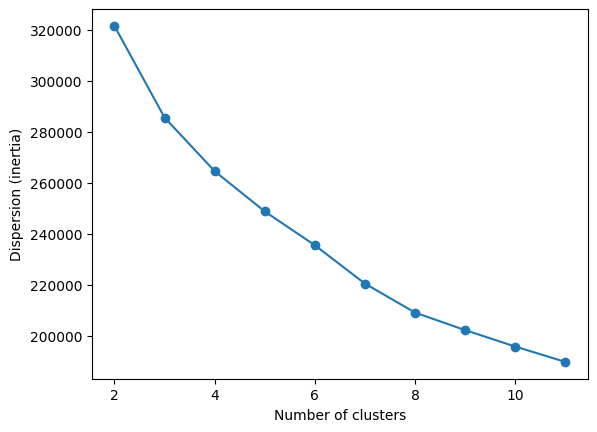

In [5]:
K_range = 11

inertias = []

for k in range(2, K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(experimental_kmeans.inertia_)

plt.plot(range(2, K_range+1), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

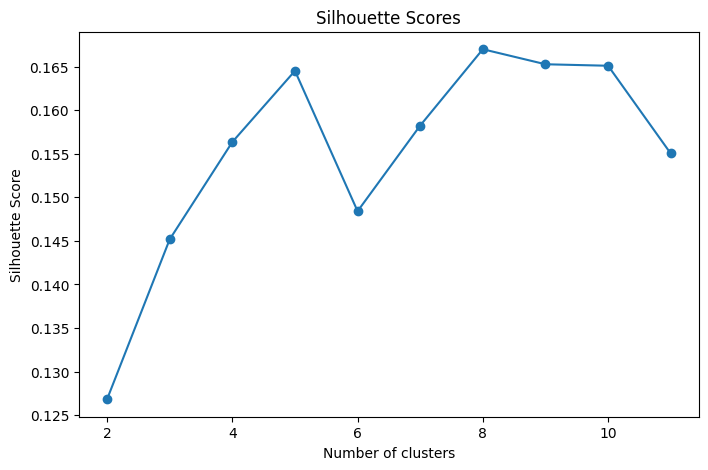

In [6]:
scores = []

for k in range(2,K_range+1):
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = experimental_kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

k=5 | silhouette=0.1645
k=8 | silhouette=0.1670


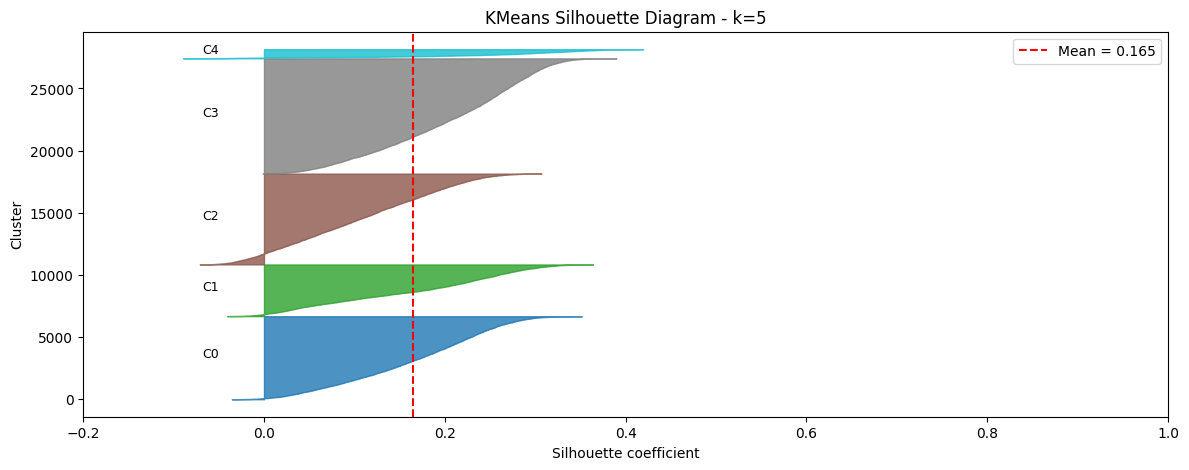

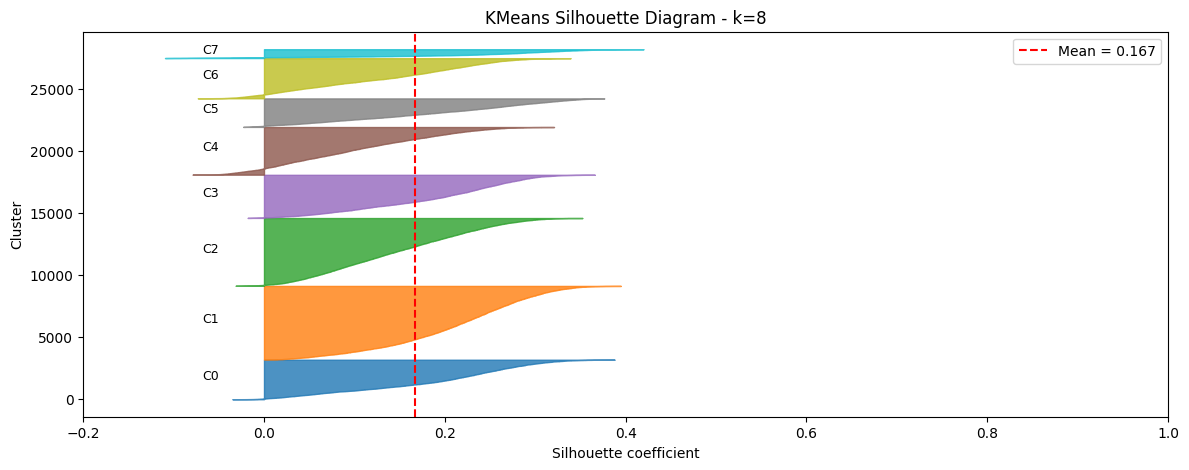

In [7]:
for k in [5,8]:
    experimental_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = experimental_kmeans.fit_predict(X_scaled)

    score = plot_silhouette(
        X_scaled,
        labels,
        title=f"KMeans Silhouette Diagram - k={k}"
    )

    print(f"k={k} | silhouette={score:.4f}")

In [21]:
kmeans = KMeans(n_clusters= 8,random_state=42, n_init=10).fit(X_scaled)
dataset['cluster_kmeans'] = kmeans.predict(X_scaled)


In [22]:
dataset["cluster_kmeans"].value_counts()

cluster_kmeans
1    5929
2    5454
4    3835
3    3470
6    3227
0    3181
5    2294
7     712
Name: count, dtype: int64

In [11]:
X['cluster_kmeans'] = dataset['cluster_kmeans']

In [12]:
X.groupby("cluster_kmeans").mean().T

cluster_kmeans,0,1,2,3,4,5,6,7
customer_age,55.627790,57.349637,60.308764,58.568876,58.448240,57.290759,33.191819,54.844101
number_complaints,0.979881,0.688818,1.164283,0.345533,0.748892,0.920227,1.759839,0.953652
distinct_stores_visited,1.628733,3.437005,4.149982,1.796254,4.572099,3.149085,2.420205,3.134831
total_children,0.719899,1.932872,1.961129,1.451873,1.161408,6.510026,2.044623,2.029494
percentage_of_products_bought_promotion,0.251677,0.129964,0.367707,0.165028,0.662252,0.203022,0.479916,0.327513
lifetime_spend_vegetables,200.878655,1744.790015,404.723322,624.698847,478.269883,825.465998,255.589712,682.883427
lifetime_spend_meat_fish,1683.884313,198.851071,1833.443894,1436.453602,1112.823990,2754.311683,1010.136040,1307.598315
lifetime_spend_electronics_videogames,10085.621188,1614.793051,3207.311331,1314.110663,936.638331,5319.251090,1326.711497,3034.390449
lifetime_spend_nonalcohol_drinks,551.314367,511.323832,646.486982,322.907781,187.289961,818.500000,247.695693,440.862360
lifetime_spend_alcohol_drinks,1065.392015,296.926463,766.686469,199.757925,283.728553,1519.366173,680.192439,645.530899


In [12]:
experimental_hierarchical = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(X_scaled)

KeyboardInterrupt: 

In [13]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(experimental_hierarchical, truncate_mode="level", p=50)
plt.show()


KeyboardInterrupt: 

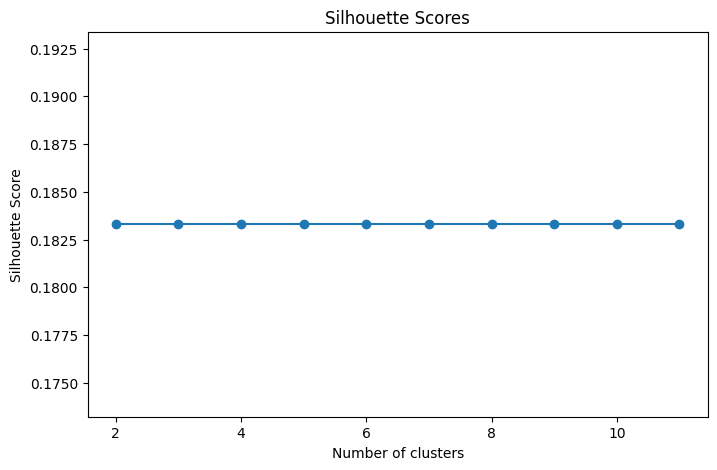

In [ ]:
scores = []

for k in range(2,K_range+1):
    experimental_hierachical = AgglomerativeClustering(n_clusters=k, linkage='ward', random_state = 42, n_init= 10)
    labels = experimental_kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [ ]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_workflow = Clusteringworkflow(hierarchical)

hierarchical_workflow.fit_and_prediction(dataset, X_scaled)

dataset.head()

NameError: name 'Clusteringworkflow' is not defined

In [ ]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'has_children',
       'year_first_transaction', 'distinct_stores_visited',
       'number_complaints', 'typical_hour', 'time_of_day',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'latitude', 'longitude', 'total_trips',
       'total_items_bought', 'average_basket_size', 'max_basket_size',
       'min_basket_size', 'unique_products_bought', 'cluster_kmeans'],
      dtype='str')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32242 entries, 3 to 40000
Data columns (total 30 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            32242 non-null  object 
 1   customer_gender                          32242 non-null  object 
 2   customer_age                             32242 non-null  int64  
 3   education_level                          32242 non-null  object 
 4   kids_home                                32242 non-null  int64  
 5   teens_home                               32242 non-null  int64  
 6   total_children                           32242 non-null  int64  
 7   has_children                             32242 non-null  int64  
 8   year_first_transaction                   32242 non-null  int64  
 9   distinct_stores_visited                  32242 non-null  int64  
 10  number_complaints                        32242 non-

In [ ]:
pd.DataFrame(
    confusion_matrix(
        dataset['cluster_kmeans'],
        dataset['cluster_agglomerativeclustering']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 4)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 4)]
)

KeyError: 'cluster_agglomerativeclustering'

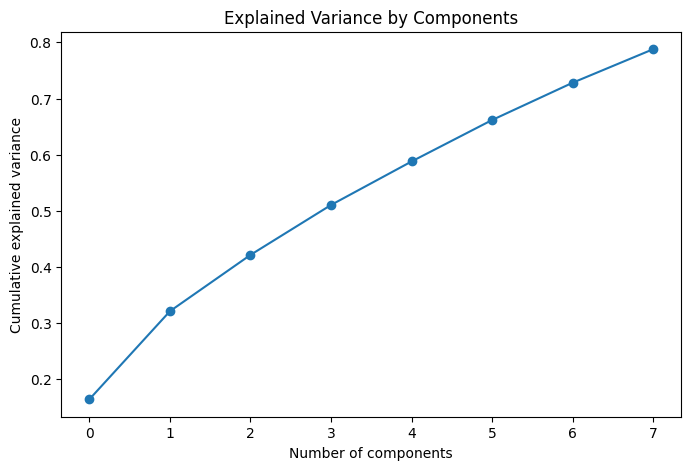

In [13]:
pca = PCA(n_components=8, random_state=42)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Explained Variance by Components')
plt.show()

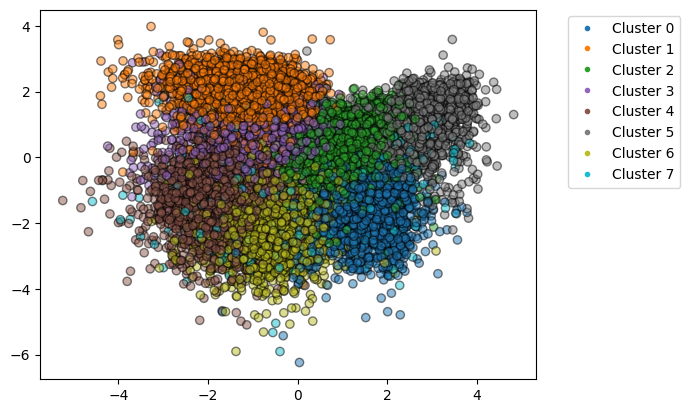

In [14]:
plot_2d_with_classes(dataset['cluster_kmeans'],components)

In [15]:
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_transformation = tsne.fit_transform(X_scaled)


c:\Users\laura\Desktop\ML II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


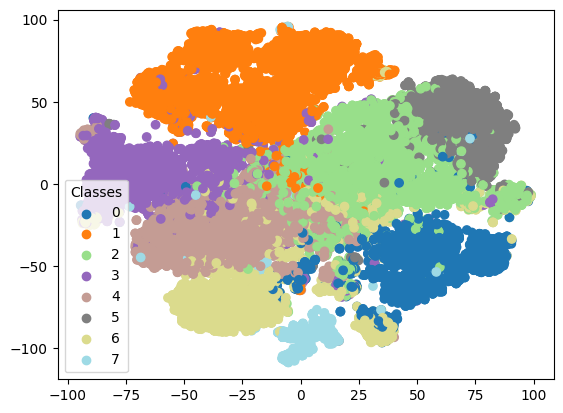

In [16]:
visualize_dimensionality_reduction(tsne_transformation, dataset['cluster_kmeans'])    


In [17]:
umap = UMAP(n_neighbors=10, min_dist=0.3, random_state=42)



umap_transformation = umap.fit_transform(X_scaled)

c:\Users\laura\Desktop\ML II\ml_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\laura\Desktop\ML II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


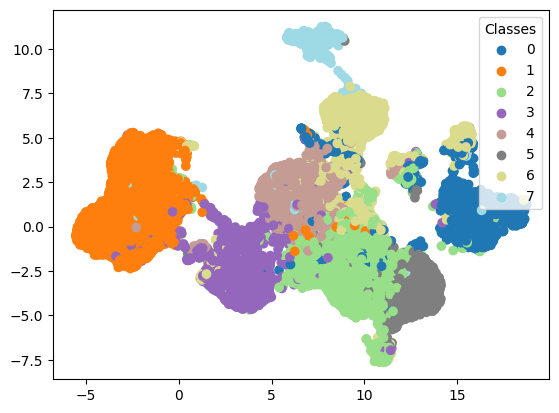

In [18]:
visualize_dimensionality_reduction(umap_transformation, dataset['cluster_kmeans'])